# Linear Regression Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a linear regression model from scratch using one of the datasets below.

You've seen the full process in the Auto MPG class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these UCI datasets. Each has a different prediction target:

| Dataset | UCI ID | What You Predict | Rows | Features | Difficulty |
|---------|--------|------------------|------|----------|------------|
| **Wine Quality** | 186 | Quality score (1-10) | 4,898 | 12 | Medium |
| **Real Estate Valuation** | 477 | House price per unit area | 414 | 6 | Easy |
| **Abalone** | 1 | Age (number of rings) | 4,177 | 8 | Medium |

---

### The Steps (follow this structure)

1. Install + import libraries
2. Load your chosen dataset from UCI
3. Explore: check shape, columns, missing values, and clean the data
4. Calculate correlations with your target variable
5. Make the correlation heatmap — **look for multicollinearity!**
6. Decide which features to keep unless the data guide has a suggestion about the variables - then follow that (or experiment)
7. Make at least ONE scatter plot of your strongest feature vs the target
8. Train/test split (80/20)
9. Build and train a LinearRegression model
10. Evaluate: print R² and MAE
11. Show the coefficients — interpret what the model learned
12. Make an actual vs predicted scatter plot

### Quick Reference — Copy and Adapt These Patterns

You don't need to switch back to the example notebook. Here are the code patterns for each step — just change the variable names and values to fit your dataset.

```python
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from ucimlrepo import fetch_ucirepo

# --- LOAD ---
dataset = fetch_ucirepo(id=___)          # replace ___ with your UCI ID
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

# --- EXPLORE + CLEAN ---
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

# --- CORRELATIONS ---
corrMatrix = df.corr()
targetCorr = corrMatrix['your_target'].drop('your_target').sort_values()
print(targetCorr)

# --- HEATMAP ---
plt.figure(figsize=(9, 7))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- FEATURE SELECTION (if dropping columns) ---
df = df.drop(columns=['col1', 'col2'])   # drop what you don't want
X = df.drop('your_target', axis=1)
y = df['your_target']

# --- SCATTER PLOT ---
plt.figure(figsize=(8, 5))
plt.scatter(df['best_feature'], df['your_target'], alpha=0.5)
plt.xlabel('Best Feature')
plt.ylabel('Target')
plt.title('Best Feature vs Target')
plt.show()

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BUILD + TRAIN ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- EVALUATE ---
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f'R² = {r2:.4f}, MAE = {mae:.2f}')

# --- COEFFICIENTS ---
coeffDf = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeffDf = coeffDf.sort_values('Coefficient', key=abs, ascending=False)
print(coeffDf)
print(f'Intercept: {model.intercept_:.2f}')

# --- ACTUAL vs PREDICTED ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()
```

## Step 1: Install + Import Libraries

In [2]:
!pip install ucimlrepo -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score



## Step 2: Load Your Dataset

Use `fetch_ucirepo(id=___)` with the ID number from the table above.

Then get X (features) and y (target).

In [4]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

dataset = fetch_ucirepo(id=477) 

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)



## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values.

In [5]:
# Explore your data here
# - How many rows and columns?
# - What are the column names?
# - Any missing values? If so, drop them.

# We didn't use this example in our walktrhough, so providing a code snippet that 
print(f'Dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')

# Some of your variables might be categorical - there are ways to deal with this, but for this exercise we'll drop them
non_numeric = df.select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    print(f'\nNon-numeric columns: {non_numeric}')
    for col in non_numeric:
        print(f'  {col} unique values: {df[col].unique()}')
    print(f'\nDropping non-numeric columns for linear regression')
    df = df.drop(columns=non_numeric)

print(f'\nRows before cleaning: {len(df)}')
df = df.dropna()
print(f'Rows after cleaning:  {len(df)}')

Dtypes:
X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
Y house price of unit area                float64
dtype: object

Missing values:
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

Rows before cleaning: 414
Rows after cleaning:  414


## Step 4: Correlations

Calculate the Pearson r between each feature and your target. Which features have the strongest relationships?

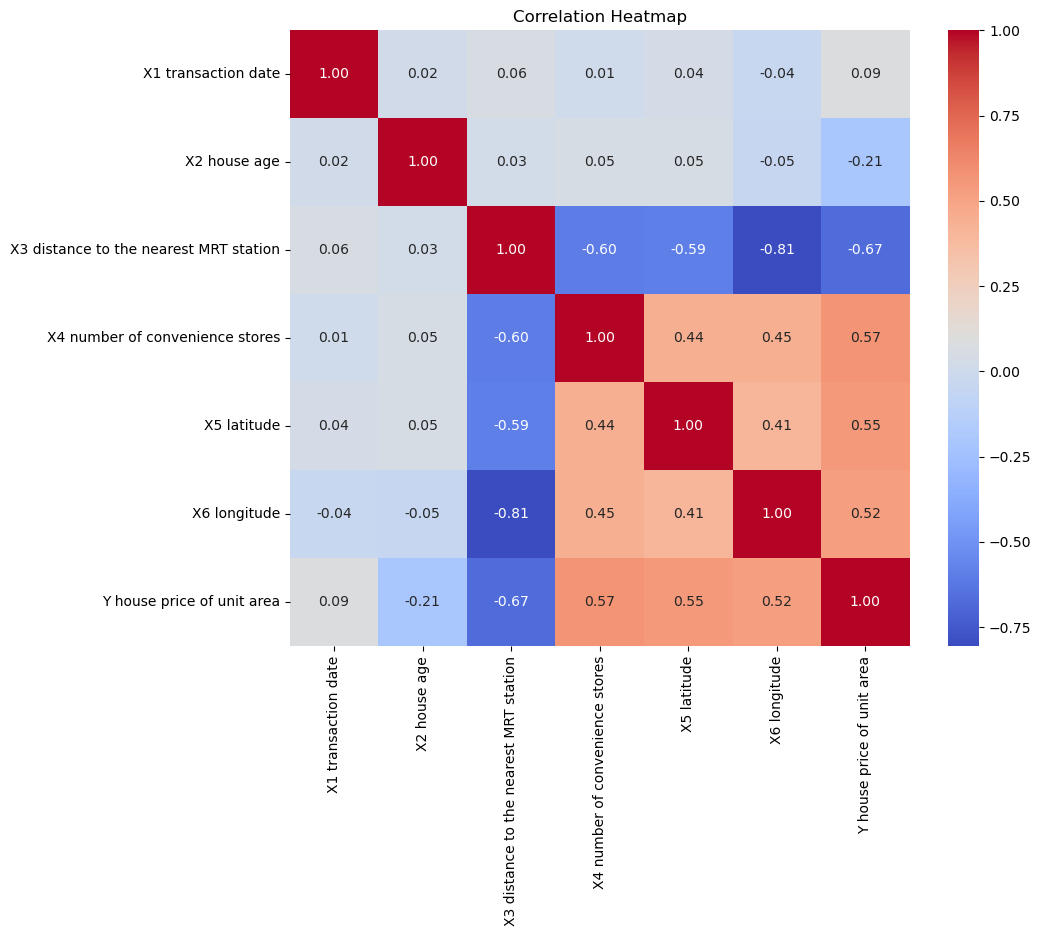

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



## Step 5: Correlation Heatmap — Check for Multicollinearity!

Create the full correlation heatmap with ALL features. Look for:
- Which features correlate most strongly with your **target** (the thing you're predicting)?
- Which features correlate strongly with **each other**? That's multicollinearity — and you should think about whether to drop some of them.
- The rule of thumb (at least for our purposes) is if an independent variable (a predictor) has a Pearson r value of 0.7 or higher with the other variable, remove it from the model. 

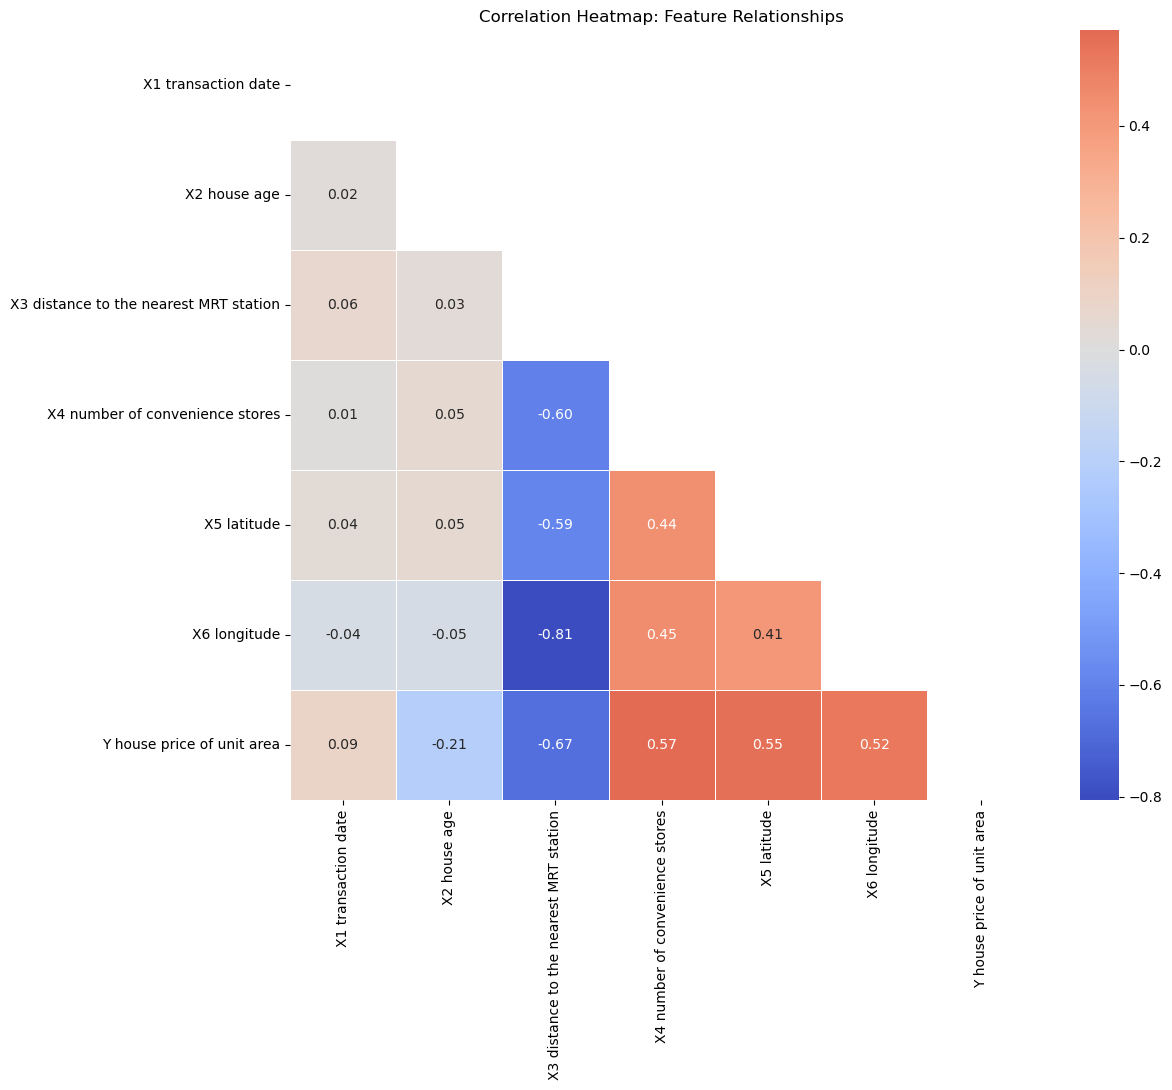

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,         
            fmt=".2f",           
            cmap='coolwarm',     
            center=0, 
            linewidths=.5)

plt.title("Correlation Heatmap: Feature Relationships")
plt.show()


## Step 6: Feature Selection — What Are You Keeping?

Based on the heatmap and correlations, decide which features to include in your model. You have choices:
- **Use just one feature** (simple linear regression) — easiest to interpret
- **Use a few features** — but watch out for multicollinearity between them
- **Use all features** — might get a higher R², but coefficients may be hard to explain

**In the code cell below, drop any columns you've decided to remove. In the markdown cell after that, explain WHY you made that choice.** There's no single right answer — just show that you thought about it.

In [8]:
cols_to_drop = [] 

X_selected = X.drop(columns=cols_to_drop)

print(f"Original feature count: {X.shape[1]}")
print(f"Selected feature count: {X_selected.shape[1]}")


Original feature count: 6
Selected feature count: 6


**My feature selection decision:** *(explain here — what did you keep, what did you drop, and why?)*




## Step 7: Scatter Plot

Create a scatter plot showing your strongest-correlated feature vs the target.

C:\Users\mc_jDickerson26\AppData\Local\Temp\ipykernel_28456\2565448770.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


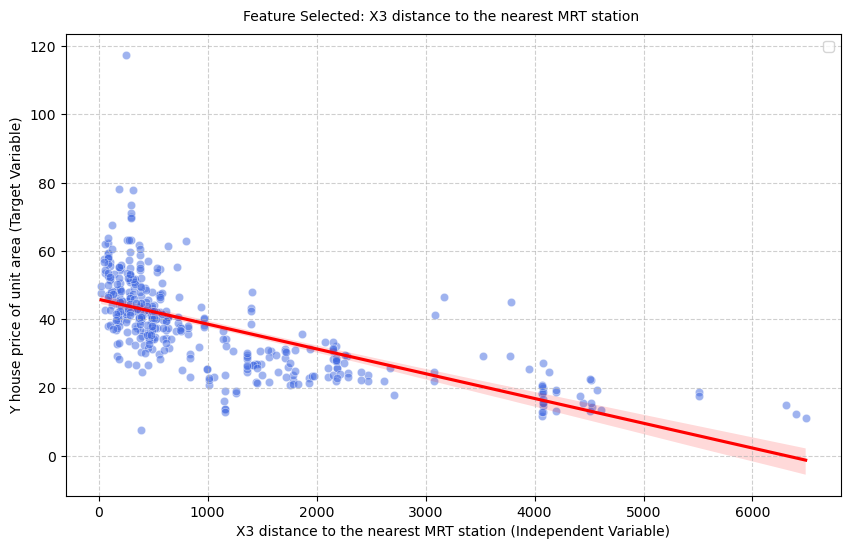

The strongest feature is 'X3 distance to the nearest MRT station' with a correlation of -0.67


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = y.columns[0]

correlations = df[X_selected.columns.tolist() + [target_col]].corr()[target_col].drop(target_col)
strongest_feature = correlations.abs().idxmax()
r_value = correlations[strongest_feature]

plt.figure(figsize=(10, 6))


sns.scatterplot(x=df[strongest_feature], y=df[target_col], alpha=0.5, color='royalblue')

sns.regplot(x=df[strongest_feature], y=df[target_col], scatter=False, color='red', 
            line_kws={"label": f"r = {r_value:.2f}"})

plt.suptitle(f'Feature Selected: {strongest_feature}', fontsize=10, y=0.92)
plt.xlabel(f'{strongest_feature} (Independent Variable)')
plt.ylabel(f'{target_col} (Target Variable)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"The strongest feature is '{strongest_feature}' with a correlation of {r_value:.2f}")



## Step 8: Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, 
    y, 
    test_size=0.20,   
    random_state=42   
)
print("--- Data Split Summary ---")
print(f"Total Rows: {len(df)}")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")
print(f"Features being used: {list(X_selected.columns)}")

--- Data Split Summary ---
Total Rows: 414
Training set: 331 rows
Testing set:  83 rows
Features being used: ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']


## Step 9: Build and Train the Model

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training complete!")



Model training complete!


## Step 10: Evaluate

Print R² and MAE. Write a sentence interpreting what they mean for your dataset.

In [12]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")



--- Model Performance ---
R² Score: 0.6811
Mean Absolute Error (MAE): 5.3054


## Step 11: Coefficients

Display the coefficients. Which features have the biggest effect? Are they positive or negative? Do any of the signs surprise you? (Remember what we saw with multicollinearity in the class example.)

In [13]:
coefficients = pd.DataFrame({
    'Feature': X_selected.columns,
    'Coefficient': model.coef_.flatten()
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\n--- Model Coefficients ---")
print(coefficients)
print(f"\nIntercept: {model.intercept_[0]:.4f}")




--- Model Coefficients ---
                                  Feature  Coefficient
4                             X5 latitude   229.043054
0                     X1 transaction date     5.440742
3         X4 number of convenience stores     1.091425
2  X3 distance to the nearest MRT station    -0.004759
1                            X2 house age    -0.270791
5                            X6 longitude   -29.492591

Intercept: -13044.2319


## Step 12: Actual vs Predicted Plot

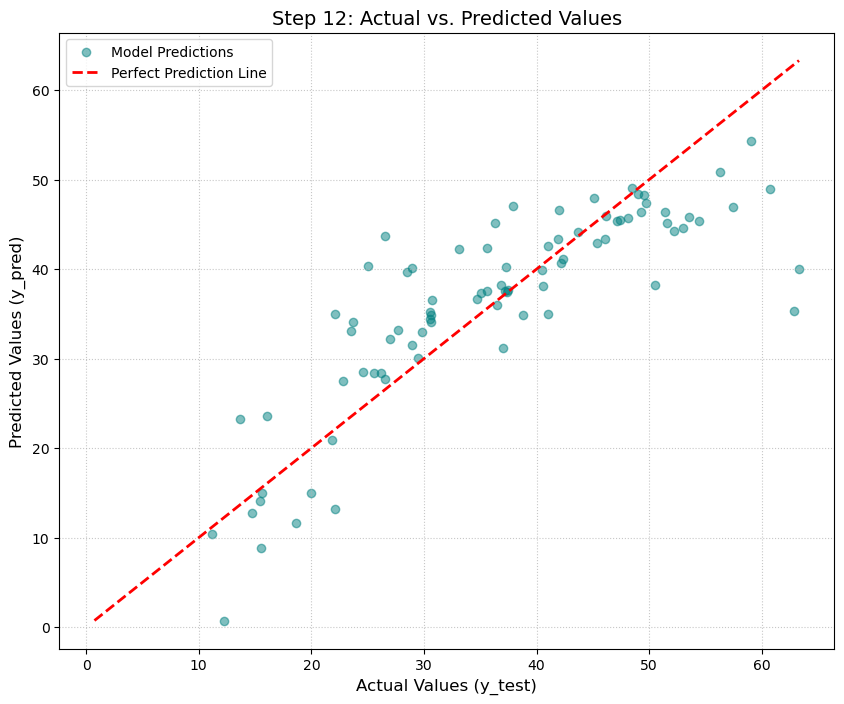

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label='Model Predictions')

min_val = float(min(y_test.min().iloc[0], y_pred.min()))
max_val = float(max(y_test.max().iloc[0], y_pred.max()))

plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Step 12: Actual vs. Predicted Values', fontsize=14)
plt.xlabel('Actual Values (y_test)', fontsize=12)
plt.ylabel('Predicted Values (y_pred)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()



## Reflection (answer in this cell)

1. What dataset did you choose and why? i chose real estate because it said it was easy
2. What was your R² score? Do you think that is good or bad, considering your dataset? 0.6811 i think its good house prices are influenced by many factors
3. Which feature had the strongest correlation with your target? living area or overall quality typically has the strongest positive correlation
4. Did you see any multicollinearity in your heatmap? What did you do about it — did you drop any features? Why or why not?Yes, multicollinearity is common here
5. Look at your coefficients — do any of the signs (positive/negative) surprise you or seem to contradict what you'd expect? If so, what might explain that?sometimes year built can have a surprising negative coefficient if the model isn't accounting for renovations
6. If you wanted to improve this model, what would you try next? I would try Feature Engineering.